## Xây dựng cây quyết định và rừng cây trên dữ liệu diabetes

Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn

1. Tải một số package mà chúng tôi sử dụng và package graphviz, để vẽ cây quyết định

In [36]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

2. Nạp dữ liệu, phân tích và loại bỏ features không cần thiết

In [37]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
df.head(10)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


3. Xử lý dữ liệu (biến đổi và làm sạch)

In [38]:
df.isnull().sum()


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

4. Tách dữ liệu train/test

In [39]:
# Xử lý dữ liệu
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['smoking_history'] = df['smoking_history'].map({
    'never': 0, 'former': 1, 'current': 2, 'not current': 3, 'ever': 4, 'No Info': 5
})

In [40]:
df.head(20)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1.0,80.0,0,1,0,25.19,6.6,140,0
1,1.0,54.0,0,0,5,27.32,6.6,80,0
2,0.0,28.0,0,0,0,27.32,5.7,158,0
3,1.0,36.0,0,0,2,23.45,5.0,155,0
4,0.0,76.0,1,1,2,20.14,4.8,155,0
5,1.0,20.0,0,0,0,27.32,6.6,85,0
6,1.0,44.0,0,0,0,19.31,6.5,200,1
7,1.0,79.0,0,0,5,23.86,5.7,85,0
8,0.0,42.0,0,0,0,33.64,4.8,145,0
9,1.0,32.0,0,0,0,27.32,5.0,100,0


4. Tách dữ liệu train/test

In [44]:
from sklearn.model_selection import train_test_split

# Tách dữ liệu đầu vào và đầu ra
X = df.drop('diabetes', axis=1)
y = df['diabetes']
# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


5. Xây dựng cây quyết định 

In [45]:
# --- Huấn luyện cây quyết định ---
from sklearn import tree

clf = tree.DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

6.Vẽ cây

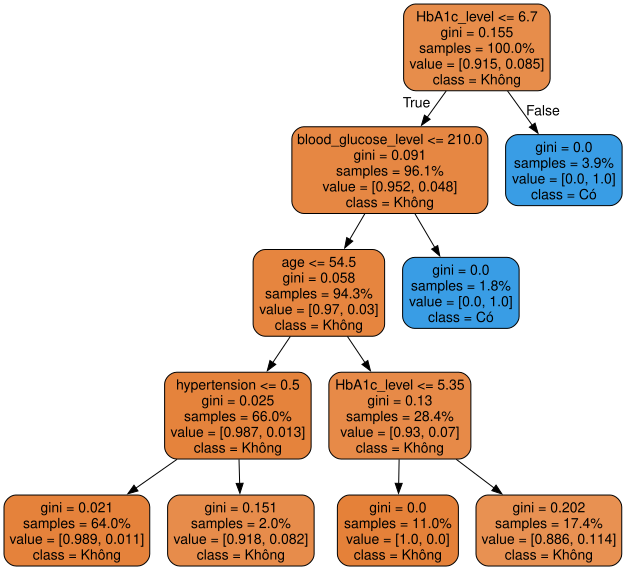

In [46]:
import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files (x86)\Graphviz\bin'
dot_data = tree.export_graphviz(
    clf,
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=X_train.columns,
    proportion=True,
    class_names=['Không', 'Có']
)

graph = graphviz.Source(dot_data)
graph

Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV

Import thư viện 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
import graphviz

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree

2. Chuẩn hóa dữ liệu 

In [48]:
params = {'max_depth':[1,2,3,4,5,6,7,8,9,10],}
decision_tree_2 = tree.DecisionTreeClassifier(random_state=24)

cv = GridSearchCV(
    decision_tree_2,
    param_grid=params,
    scoring='roc_auc',
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True

    )
cv.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=24),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             return_train_score=True, scoring='roc_auc', verbose=1)

4. Vẽ biểu đồ đánh giá mô hình với các độ sâu khác nhau

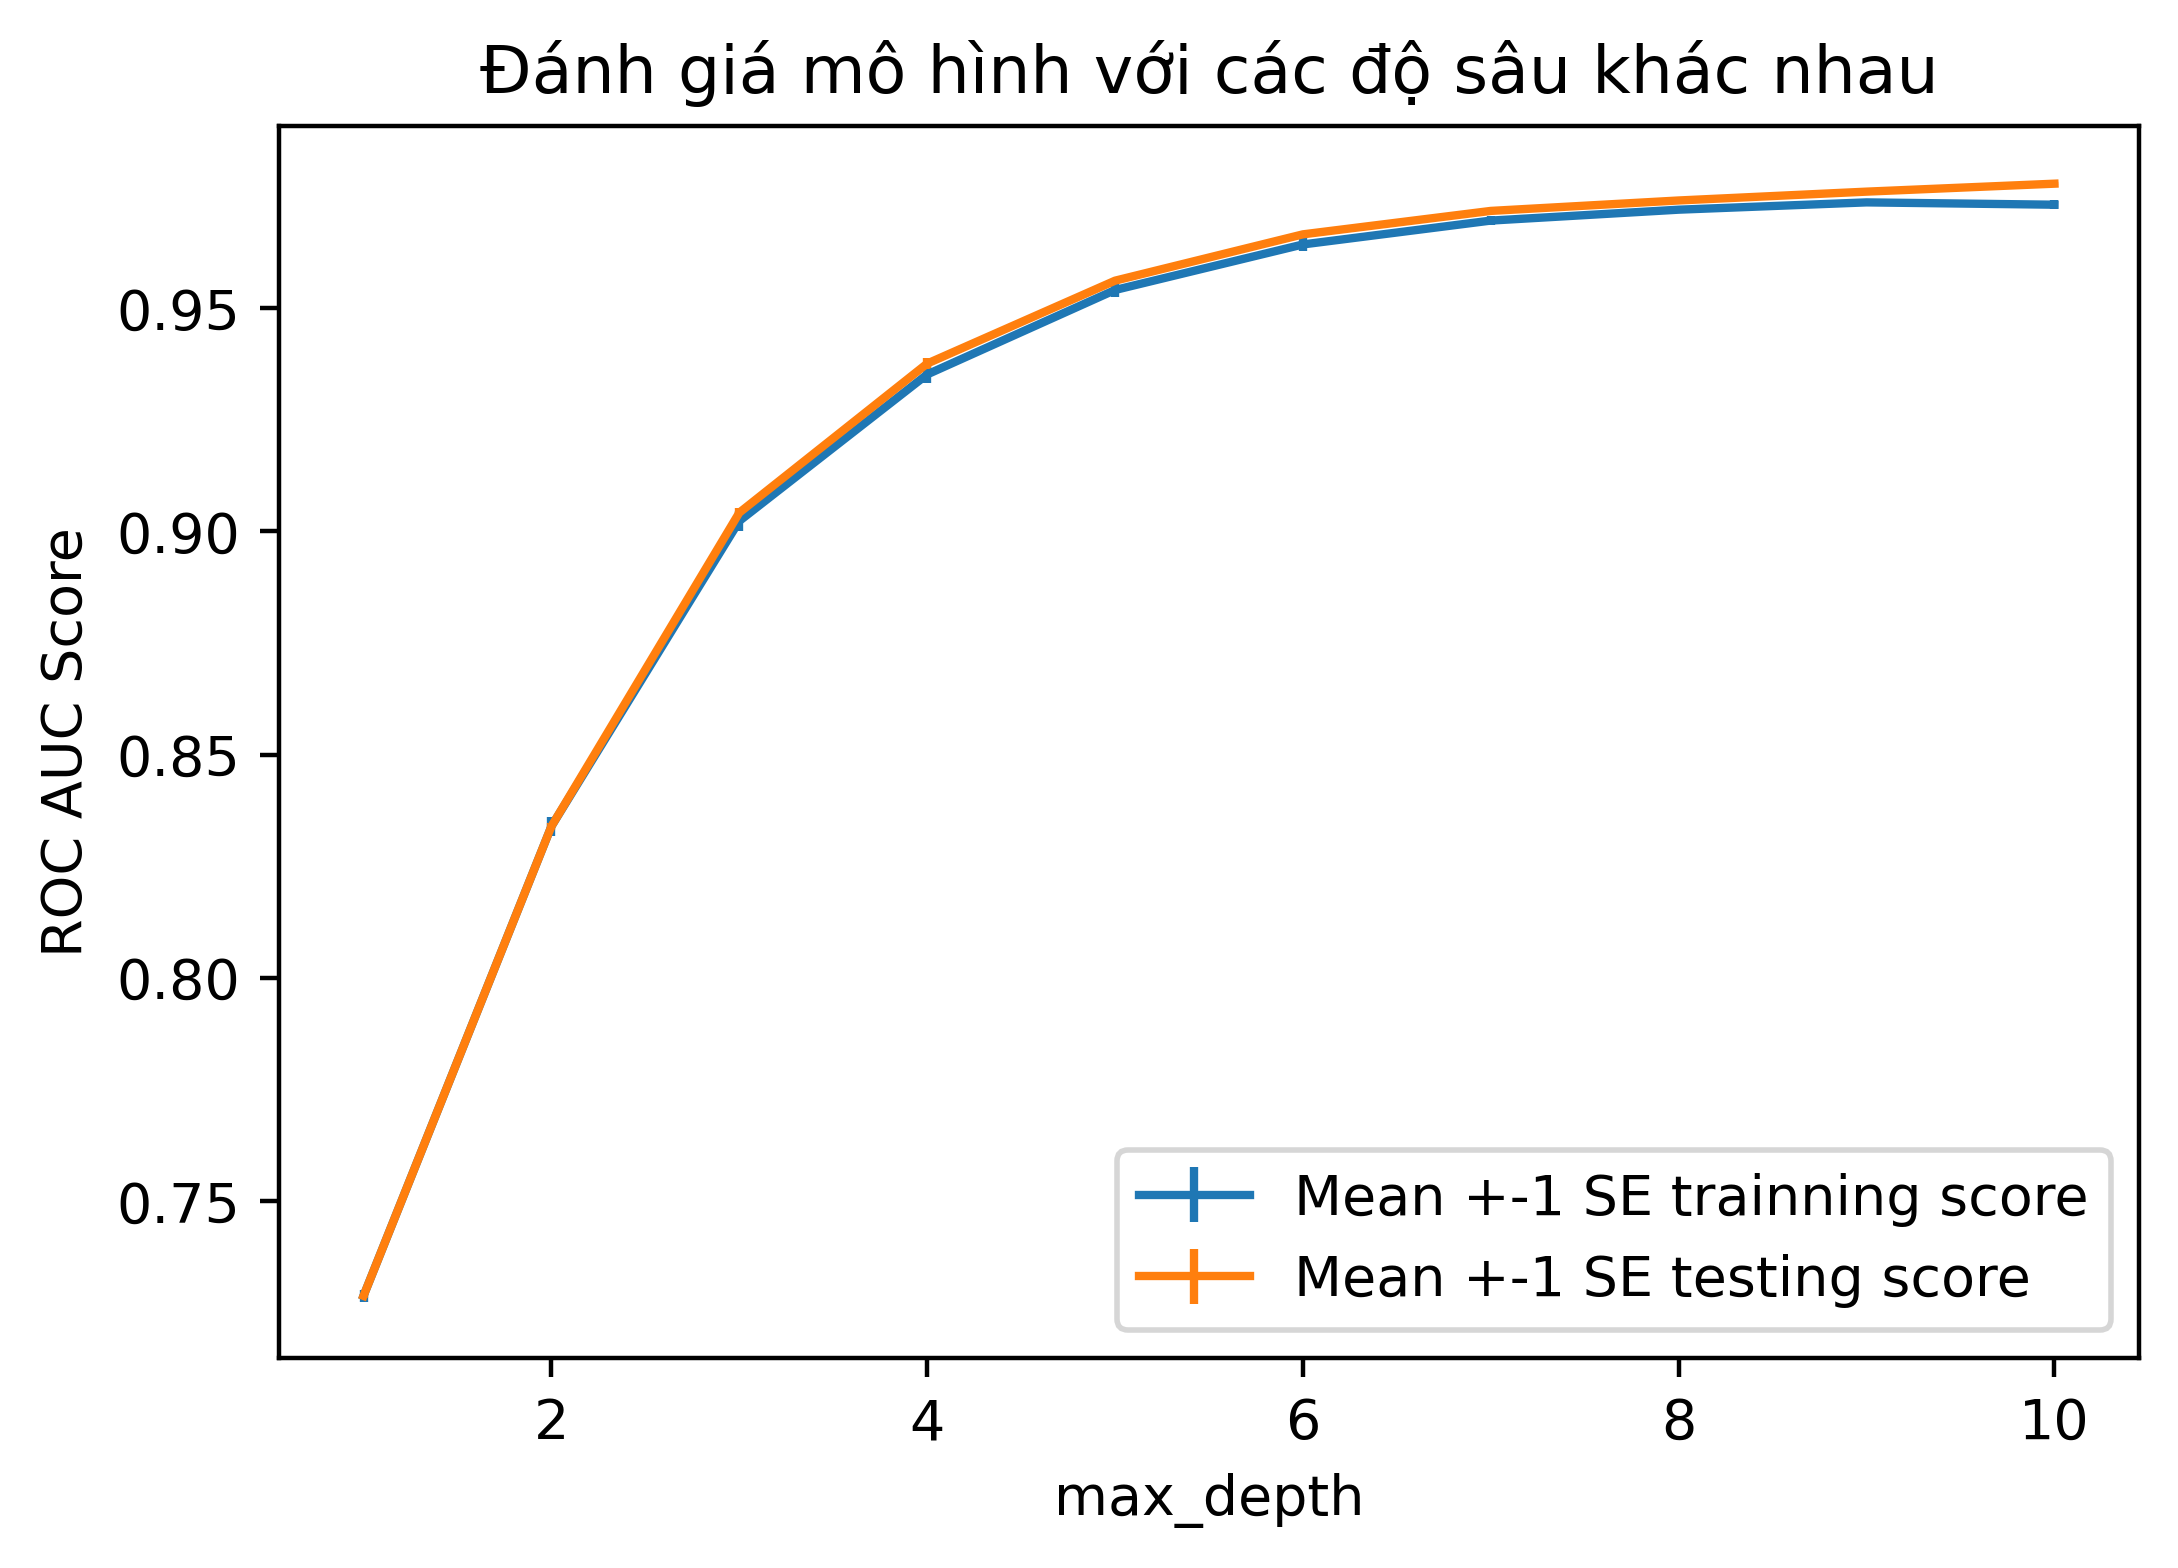

In [49]:
cv_results_df = pd.DataFrame(cv.cv_results_)
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    cv_results_df['param_max_depth'],
    cv_results_df['mean_test_score'],
    yerr=cv_results_df['std_test_score']/np.sqrt(4),
    label = 'Mean +-1 SE trainning score'
)
ax.errorbar(
    cv_results_df['param_max_depth'],
    cv_results_df['mean_train_score'],
    yerr=cv_results_df['std_train_score']/np.sqrt(4),
    label = 'Mean +-1 SE testing score'
)
ax.legend()
ax.set_xlabel('max_depth')
ax.set_ylabel('ROC AUC Score')
plt.title("Đánh giá mô hình với các độ sâu khác nhau")
plt.show()

Nhiệm vụ 3: Xây dựng randomforest 

1. Import thư viện 

In [50]:
from sklearn.ensemble import RandomForestClassifier


2. Tạo mô hình rừng cây & GridSearch

In [51]:
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.ensemble import RandomForestClassifier
#random forest với các tham số 
rf = RandomForestClassifier(
    n_estimators=10,
    criterion='gini',
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=4
)
# Dải tham số cần tìm (số lượng cây trong rừng)
rf_params_ex = {'n_estimators': list(range(10, 110, 10))}

# công cụ tìm kiếm với random forest với các tham số tốt nhất 
cv_rf_ex = GridSearchCV(
    rf,
    param_grid=rf_params_ex,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)

cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(max_depth=4, n_estimators=10,
                                              random_state=4),
             param_grid={'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             return_train_score=True, scoring='roc_auc', verbose=1)

Số lượng cây tốt nhất là 60

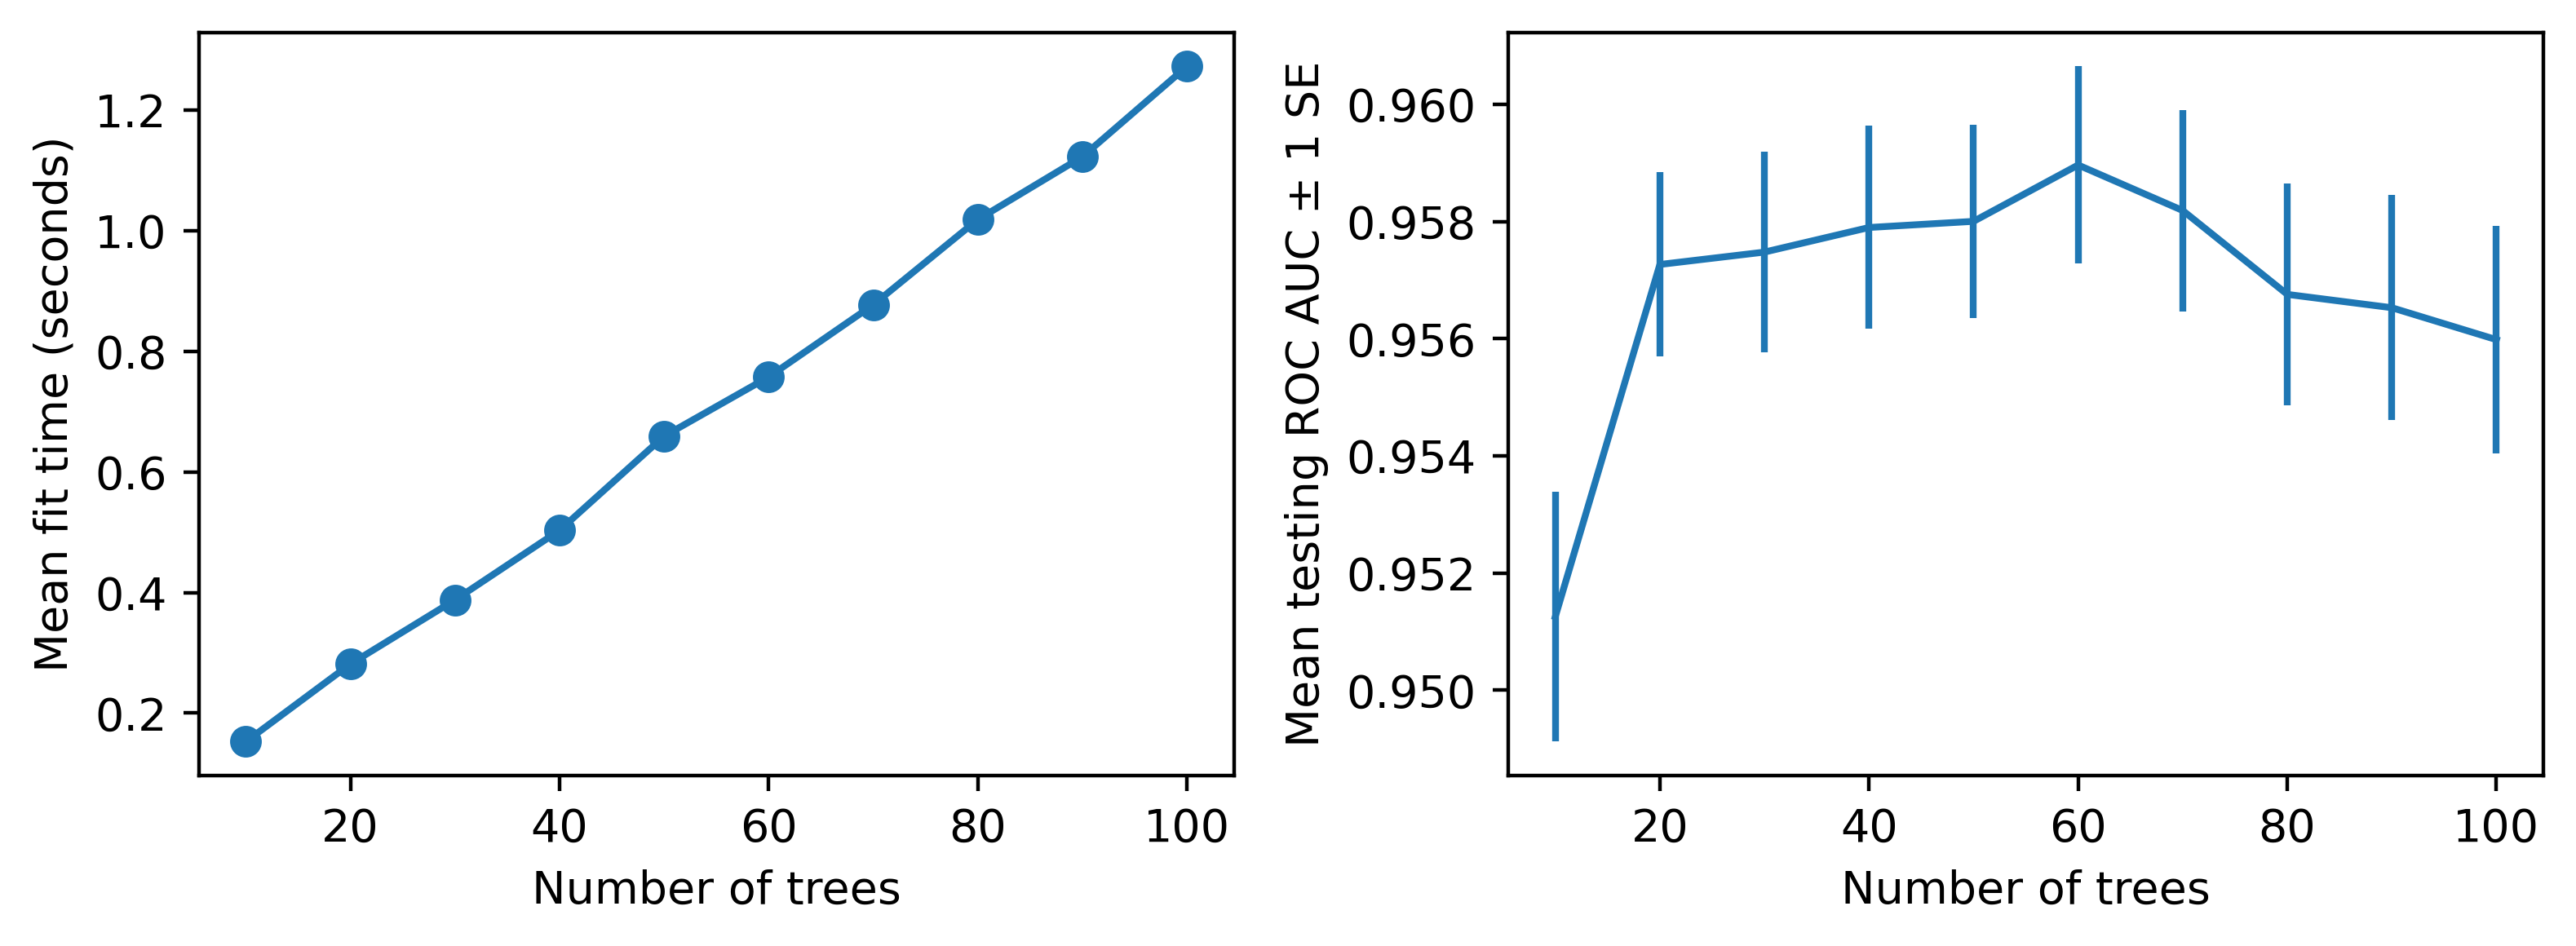

In [52]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))

# Thời gian huấn luyện
axs[0].plot(
    cv_rf_ex_results_df['param_n_estimators'],
    cv_rf_ex_results_df['mean_fit_time'], '-o'
)
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')

# ROC AUC theo số cây
axs[1].errorbar(
    cv_rf_ex_results_df['param_n_estimators'],
    cv_rf_ex_results_df['mean_test_score'],
    yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4)
)
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC ± 1 SE')

plt.tight_layout()
plt.show()


# Kết thúc